Price data stored in memory cache.
Cached datasets: 4

DATA
Initial capital: £10,000.00
Actual start:    2024-08-19
Actual end:      2026-08-18
Trading days:    506

Weekly 1-year windows: 53
Allocations tested: 231
Total portfolio-window tests: 12,243
Robust Pareto portfolios: 65

YOUR 70 / 10 / 20
Equity:  70%
Bonds:   10%
Gold:    20%

10th percentile CAGR:       20.62%
Median CAGR:                25.66%
90th percentile volatility: 13.60%
90th percentile drawdown:   9.87%
95th percentile drawdown:   9.89%
99th percentile drawdown:   9.90%

BALANCED ROBUST PARETO CHOICE
Equity:  50%
Bonds:   30%
Gold:    20%

10th percentile CAGR:       17.28%
Median CAGR:                21.54%
90th percentile volatility: 11.33%
90th percentile drawdown:   8.85%
95th percentile drawdown:   8.88%
99th percentile drawdown:   8.90%

ROBUST PARETO PORTFOLIOS
 Equity %  Bonds %  Gold % CAGR P10 Median CAGR Vol P90 DD P90 DD P95 DD P99
        5        0      95   26.79%      42.80%  23.61% 23.00% 23.79% 2

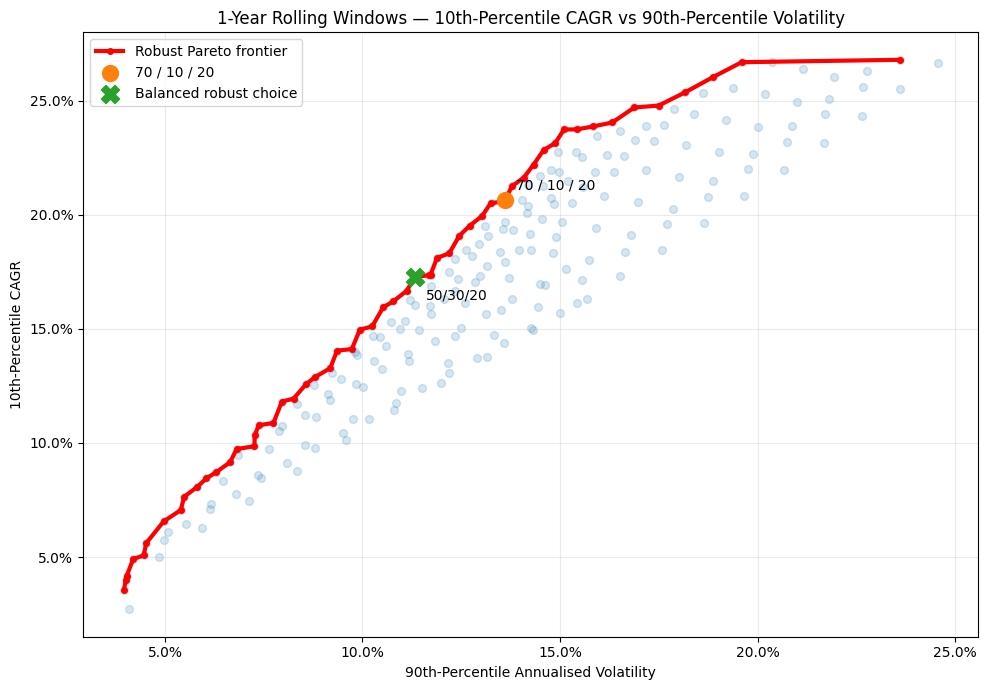

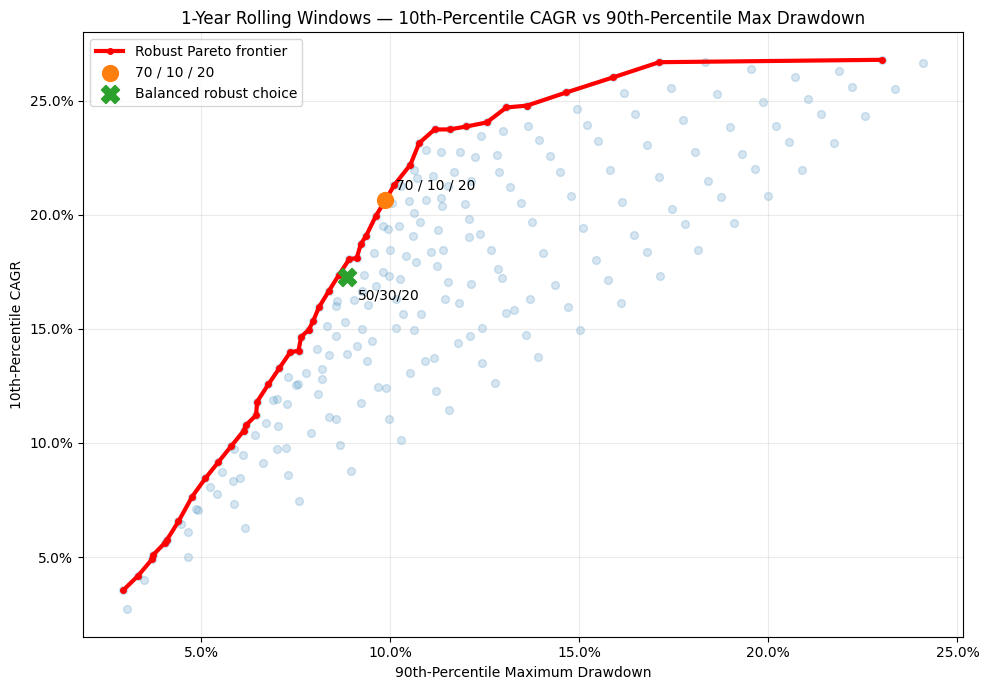


COMPLETE
Full results saved to: rolling_1_year_portfolio_results.csv
Robust Pareto set saved to: robust_pareto_portfolios.csv


In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from IPython import get_ipython


# ============================================================
# SETTINGS
# ============================================================

START_DATE = "2024-08-19"

# yfinance end date is exclusive.
# Therefore 2026-08-19 requests data through 2026-08-18.
END_DATE = "2026-08-19"

INITIAL_CAPITAL = 10_000

# 5% increments gives 231 Equity/Bond/Gold combinations
WEIGHT_STEP = 5

# Each weekly entry is held for one complete year
HOLDING_YEARS = 1


# ============================================================
# ROBUST OPTIMISATION SETTINGS
# ============================================================

# We treat the 10th percentile CAGR as the relatively
# adverse return outcome.
RETURN_PERCENTILE = 0.10

# We treat the 90th percentile volatility and drawdown
# as relatively adverse risk outcomes.
RISK_PERCENTILE = 0.90


# ============================================================
# DATA SANITY CHECKS
# ============================================================

MAX_ABS_DAILY_MOVE = 0.40

MIN_TRADING_DAYS = 252


# ============================================================
# PORTFOLIO
# ============================================================

# Equity sleeve.
#
# The equity allocation is always divided equally across
# these five ETFs.

equities = [
    "CSP1.L",
    "VUKG.L",
    "VERG.L",
    "SJPA.L",
    "EMIM.L",
]


# Bond sleeve
bond = "VAGS.L"


# Gold sleeve
gold = "SGLN.L"


tickers = (
    equities
    + [bond, gold]
)


# ============================================================
# JUPYTER IN-MEMORY PRICE CACHE
# ============================================================

def get_price_cache():
    """
    Return an in-memory cache stored in Jupyter's user
    namespace.

    The cache survives rerunning notebook cells as long as
    the same Jupyter kernel remains alive.

    If this script is run outside Jupyter/IPython, it falls
    back to a normal global Python dictionary.
    """

    ipython = get_ipython()

    # --------------------------------------------------------
    # Normal Python fallback
    # --------------------------------------------------------

    if ipython is None:

        global _price_cache

        if "_price_cache" not in globals():
            _price_cache = {}

        return _price_cache


    # --------------------------------------------------------
    # Jupyter persistent user namespace
    # --------------------------------------------------------

    namespace = (
        ipython.user_ns
    )

    if "_price_cache" not in namespace:

        namespace[
            "_price_cache"
        ] = {}

    return namespace[
        "_price_cache"
    ]


def get_prices(
    tickers,
    start,
    end,
):
    """
    Download adjusted historical prices once and cache them.

    Cached data are reused when all of these are unchanged:

        tickers
        start date
        end date

    Changing any of them creates a new cache entry.
    """

    cache = (
        get_price_cache()
    )

    key = (
        tuple(tickers),
        start,
        end,
    )


    # --------------------------------------------------------
    # CACHE HIT
    # --------------------------------------------------------

    if key in cache:

        print(
            "Using cached price data."
        )

        return (
            cache[key]
            .copy()
        )


    # --------------------------------------------------------
    # CACHE MISS
    # --------------------------------------------------------

    print(
        "Downloading historical prices..."
    )

    data = yf.download(
        tickers,
        start=start,
        end=end,
        auto_adjust=True,
        repair=True,
        progress=False,
    )


    if data.empty:

        raise RuntimeError(
            "yfinance returned no data."
        )


    prices = (
        data["Close"]
        .reindex(
            columns=tickers
        )
        .sort_index()
    )


    # Store raw downloaded Close prices in memory
    cache[key] = (
        prices.copy()
    )


    print(
        "Price data stored in memory cache."
    )


    return (
        prices.copy()
    )


# ============================================================
# GET PRICE DATA
# ============================================================

prices = get_prices(
    tickers,
    START_DATE,
    END_DATE,
)


# ============================================================
# CACHE INFORMATION
# ============================================================

cache = get_price_cache()

print(
    f"Cached datasets: "
    f"{len(cache)}"
)


# ============================================================
# VALIDATE DATA
# ============================================================

# Check that every ETF returned at least some historical data.

missing = [
    ticker
    for ticker in tickers
    if prices[ticker].isna().all()
]


if missing:

    raise RuntimeError(
        "No historical data returned for: "
        + ", ".join(missing)
    )


# ============================================================
# USE ONLY COMMON TRADING DATES
# ============================================================

# No forward filling is performed.
#
# We only use days for which all seven ETFs have a price.

prices = (
    prices
    .dropna()
)


# ============================================================
# MINIMUM HISTORY CHECK
# ============================================================

if len(prices) < MIN_TRADING_DAYS:

    raise RuntimeError(
        f"Only {len(prices)} common trading days found."
    )


# ============================================================
# PRICE VALIDITY CHECK
# ============================================================

if (
    prices <= 0
).any().any():

    raise RuntimeError(
        "Zero or negative prices detected."
    )


# ============================================================
# SUSPICIOUS DAILY MOVE CHECK
# ============================================================

asset_returns = (
    prices
    .pct_change(
        fill_method=None
    )
)


suspicious = (
    asset_returns.abs()
    > MAX_ABS_DAILY_MOVE
)


if suspicious.any().any():

    rows, cols = (
        np.where(
            suspicious
        )
    )


    examples = [
        (
            f"{asset_returns.index[r].date()} "
            f"{asset_returns.columns[c]}: "
            f"{asset_returns.iloc[r, c]:.2%}"
        )
        for r, c in zip(
            rows[:20],
            cols[:20],
        )
    ]


    raise RuntimeError(
        "Suspicious daily price moves detected:\n"
        + "\n".join(examples)
    )


# ============================================================
# DATA INFORMATION
# ============================================================

print()

print(
    "=" * 70
)

print(
    "DATA"
)

print(
    "=" * 70
)


print(
    f"Initial capital: "
    f"£{INITIAL_CAPITAL:,.2f}"
)

print(
    f"Actual start:    "
    f"{prices.index[0].date()}"
)

print(
    f"Actual end:      "
    f"{prices.index[-1].date()}"
)

print(
    f"Trading days:    "
    f"{len(prices):,}"
)


# ============================================================
# CREATE ALL ALLOCATIONS
# ============================================================

# With 5% steps and three sleeves that sum to 100%,
# there are 231 possible allocations.

weight_rows = []


for equity_pct in range(
    0,
    101,
    WEIGHT_STEP,
):


    for bond_pct in range(
        0,
        101 - equity_pct,
        WEIGHT_STEP,
    ):


        gold_pct = (
            100
            - equity_pct
            - bond_pct
        )


        # ----------------------------------------------------
        # EQUITY SLEEVE
        # ----------------------------------------------------

        # Divide the total equity allocation equally
        # across the five equity ETFs.

        equity_weight = (
            equity_pct
            / 100
            / len(equities)
        )


        weight_rows.append({

            "Equity %":
                equity_pct,

            "Bonds %":
                bond_pct,

            "Gold %":
                gold_pct,


            **{
                ticker:
                    equity_weight
                for ticker
                in equities
            },


            bond:
                bond_pct / 100,


            gold:
                gold_pct / 100,
        })


weight_df = (
    pd.DataFrame(
        weight_rows
    )
)


# ============================================================
# VERIFY WEIGHT GRID
# ============================================================

if (
    WEIGHT_STEP == 5
    and len(weight_df) != 231
):

    raise RuntimeError(
        f"Expected 231 portfolios, "
        f"got {len(weight_df)}."
    )


# ============================================================
# WEIGHT MATRIX
# ============================================================

# Shape:
#
#     231 portfolios
#     ×
#     7 ETFs

W = (
    weight_df[tickers]
    .to_numpy()
)


# ============================================================
# CREATE WEEKLY 1-YEAR ENTRY WINDOWS
# ============================================================

# We only test weekly entry dates for which a complete
# subsequent one-year holding period exists.

last_possible_start = (
    prices.index[-1]
    - pd.DateOffset(
        years=HOLDING_YEARS
    )
)


weekly_anchors = (
    pd.date_range(
        start=prices.index[0],
        end=last_possible_start,
        freq="W-MON",
    )
)


# ============================================================
# MAP WEEKLY ANCHORS TO TRADING DAYS
# ============================================================

# If Monday is not a trading day, searchsorted moves the
# entry to the next available common trading day.

start_positions = (
    prices.index
    .searchsorted(
        weekly_anchors
    )
)


start_positions = (
    np.unique(
        start_positions[
            start_positions
            < len(prices)
        ]
    )
)


# ============================================================
# BUILD VALID ONE-YEAR WINDOWS
# ============================================================

windows = []


for start_pos in start_positions:


    start_date = (
        prices.index[
            start_pos
        ]
    )


    target_end = (
        start_date
        + pd.DateOffset(
            years=HOLDING_YEARS
        )
    )


    # --------------------------------------------------------
    # END DATE
    # --------------------------------------------------------

    # Use the final available trading day on or before
    # the exact one-year target date.

    end_pos = (
        prices.index
        .searchsorted(
            target_end,
            side="right",
        )
        - 1
    )


    if end_pos <= start_pos:

        continue


    # --------------------------------------------------------
    # ACTUAL ELAPSED YEARS
    # --------------------------------------------------------

    actual_years = (
        (
            prices.index[end_pos]
            - start_date
        ).days
        / 365.25
    )


    # --------------------------------------------------------
    # REQUIRE ESSENTIALLY ONE FULL YEAR
    # --------------------------------------------------------

    if (
        actual_years
        >= HOLDING_YEARS - 0.03
    ):

        windows.append(
            (
                start_pos,
                end_pos,
                actual_years,
            )
        )


# ============================================================
# WINDOW CHECK
# ============================================================

if not windows:

    raise RuntimeError(
        "No valid rolling windows found."
    )


print()

print(
    f"Weekly {HOLDING_YEARS}-year windows: "
    f"{len(windows):,}"
)

print(
    f"Allocations tested: "
    f"{len(weight_df):,}"
)

print(
    "Total portfolio-window tests: "
    f"{len(windows) * len(weight_df):,}"
)


# ============================================================
# ROLLING BACKTEST
# ============================================================

cagr_windows = []

vol_windows = []

dd_windows = []


for (
    start_pos,
    end_pos,
    actual_years,
) in windows:


    # --------------------------------------------------------
    # PRICE SEGMENT
    # --------------------------------------------------------

    segment = (
        prices
        .iloc[
            start_pos:
            end_pos + 1
        ]
        .to_numpy()
    )


    # --------------------------------------------------------
    # NORMALISE EACH ETF
    # --------------------------------------------------------

    # Every ETF starts at 1.0 for each new weekly entry.

    relative = (
        segment
        / segment[0]
    )


    # --------------------------------------------------------
    # PORTFOLIO VALUES
    # --------------------------------------------------------

    # Calculate all 231 allocations simultaneously.
    #
    # IMPORTANT:
    #
    # There is NO rebalancing during the one-year period.
    #
    # Weights represent the allocation at the initial
    # investment date only. Holdings then drift naturally.

    values = (
        INITIAL_CAPITAL
        * (
            relative
            @ W.T
        )
    )


    # ========================================================
    # CAGR
    # ========================================================

    final_growth = (
        values[-1]
        / INITIAL_CAPITAL
    )


    cagrs = (
        final_growth
        ** (
            1
            / actual_years
        )
        - 1
    )


    # ========================================================
    # ANNUALISED VOLATILITY
    # ========================================================

    daily_returns = (
        values[1:]
        / values[:-1]
        - 1
    )


    volatilities = (
        daily_returns.std(
            axis=0,
            ddof=1,
        )
        * np.sqrt(252)
    )


    # ========================================================
    # MAXIMUM DRAWDOWN
    # ========================================================

    running_max = (
        np.maximum.accumulate(
            values,
            axis=0,
        )
    )


    drawdowns = (
        values
        / running_max
        - 1
    )


    # Store maximum drawdown as a positive magnitude.
    #
    # Example:
    #
    #     -20% drawdown
    #
    # becomes:
    #
    #      20%

    max_drawdowns = (
        -drawdowns.min(
            axis=0
        )
    )


    # ========================================================
    # STORE WINDOW RESULTS
    # ========================================================

    cagr_windows.append(
        cagrs
    )

    vol_windows.append(
        volatilities
    )

    dd_windows.append(
        max_drawdowns
    )


# ============================================================
# CONVERT TO MATRICES
# ============================================================

# Shape:
#
#     weekly entry windows
#     ×
#     231 portfolios

cagr_windows = (
    np.vstack(
        cagr_windows
    )
)

vol_windows = (
    np.vstack(
        vol_windows
    )
)

dd_windows = (
    np.vstack(
        dd_windows
    )
)


# ============================================================
# ENTRY-TIMING DISTRIBUTIONS
# ============================================================

summary = (
    weight_df[
        [
            "Equity %",
            "Bonds %",
            "Gold %",
        ]
    ]
    .copy()
)


# ============================================================
# CAGR STATISTICS
# ============================================================

summary[
    "CAGR P10"
] = np.quantile(
    cagr_windows,
    0.10,
    axis=0,
)


summary[
    "Median CAGR"
] = np.median(
    cagr_windows,
    axis=0,
)


summary[
    "CAGR P90"
] = np.quantile(
    cagr_windows,
    0.90,
    axis=0,
)


# ============================================================
# VOLATILITY STATISTICS
# ============================================================

summary[
    "Median Volatility"
] = np.median(
    vol_windows,
    axis=0,
)


summary[
    "Vol P90"
] = np.quantile(
    vol_windows,
    0.90,
    axis=0,
)


# ============================================================
# MAXIMUM DRAWDOWN STATISTICS
# ============================================================

summary[
    "Median DD"
] = np.median(
    dd_windows,
    axis=0,
)


summary[
    "DD P90"
] = np.quantile(
    dd_windows,
    0.90,
    axis=0,
)


summary[
    "DD P95"
] = np.quantile(
    dd_windows,
    0.95,
    axis=0,
)


summary[
    "DD P99"
] = np.quantile(
    dd_windows,
    0.99,
    axis=0,
)


# ============================================================
# ROBUST 3-OBJECTIVE PARETO SET
# ============================================================

# The Pareto optimisation uses:
#
# MAXIMISE:
#
#     CAGR P10
#
# MINIMISE:
#
#     Vol P90
#     DD P90
#
#
# DD P95 and DD P99 are reported for additional tail-risk
# information but are not currently separate Pareto
# optimisation objectives.


returns = (
    summary[
        "CAGR P10"
    ]
    .to_numpy()
)


volatility = (
    summary[
        "Vol P90"
    ]
    .to_numpy()
)


drawdown = (
    summary[
        "DD P90"
    ]
    .to_numpy()
)


is_pareto = (
    np.ones(
        len(summary),
        dtype=bool,
    )
)


# ============================================================
# TEST PARETO DOMINANCE
# ============================================================

for i in range(
    len(summary)
):


    # Portfolio i is dominated if another portfolio has:
    #
    # equal or greater P10 CAGR
    # equal or lower P90 volatility
    # equal or lower P90 drawdown
    #
    # AND is strictly better on at least one criterion.


    dominated = (
        (returns >= returns[i])
        &
        (volatility <= volatility[i])
        &
        (drawdown <= drawdown[i])
        &
        (
            (returns > returns[i])
            |
            (volatility < volatility[i])
            |
            (drawdown < drawdown[i])
        )
    )


    if dominated.any():

        is_pareto[i] = False


robust_pareto = (
    summary[
        is_pareto
    ]
    .copy()
)


print(
    f"Robust Pareto portfolios: "
    f"{len(robust_pareto)}"
)


# ============================================================
# BALANCED ROBUST PARETO CHOICE
# ============================================================

# Pareto optimisation gives a set rather than one unique
# optimum.
#
# To choose one representative portfolio, normalise:
#
#     CAGR P10
#     Vol P90
#     DD P90
#
# and calculate distance from an ideal portfolio with:
#
#     maximum return
#     minimum volatility
#     minimum drawdown


def scale01(series):
    """
    Scale a pandas Series to the range 0 to 1.
    """

    span = (
        series.max()
        - series.min()
    )


    if span == 0:

        return (
            pd.Series(
                0.0,
                index=series.index,
            )
        )


    return (
        (
            series
            - series.min()
        )
        / span
    )


pareto_choice = (
    robust_pareto
    .copy()
)


# ============================================================
# RETURN GOODNESS
# ============================================================

# Higher CAGR is better.

return_good = (
    scale01(
        pareto_choice[
            "CAGR P10"
        ]
    )
)


# ============================================================
# VOLATILITY GOODNESS
# ============================================================

# Lower volatility is better.

vol_good = (
    1
    - scale01(
        pareto_choice[
            "Vol P90"
        ]
    )
)


# ============================================================
# DRAWDOWN GOODNESS
# ============================================================

# Lower drawdown is better.

dd_good = (
    1
    - scale01(
        pareto_choice[
            "DD P90"
        ]
    )
)


# ============================================================
# DISTANCE TO IDEAL
# ============================================================

pareto_choice[
    "Distance to Ideal"
] = np.sqrt(

    (1 - return_good) ** 2

    +

    (1 - vol_good) ** 2

    +

    (1 - dd_good) ** 2

)


choice = (
    pareto_choice
    .nsmallest(
        1,
        "Distance to Ideal",
    )
    .iloc[0]
)


# ============================================================
# FIND 70 / 10 / 20
# ============================================================

current = (
    summary[
        (
            summary[
                "Equity %"
            ] == 70
        )
        &
        (
            summary[
                "Bonds %"
            ] == 10
        )
        &
        (
            summary[
                "Gold %"
            ] == 20
        )
    ]
)


if len(current) != 1:

    raise RuntimeError(
        "70/10/20 portfolio not found."
    )


current = (
    current.iloc[0]
)


# ============================================================
# PRINT INDIVIDUAL PORTFOLIO
# ============================================================

def print_portfolio(
    title,
    row,
):
    """
    Print the main robust statistics for one allocation.
    """

    print()

    print(
        "=" * 70
    )

    print(
        title
    )

    print(
        "=" * 70
    )


    print(
        f"Equity:  "
        f"{int(row['Equity %'])}%"
    )

    print(
        f"Bonds:   "
        f"{int(row['Bonds %'])}%"
    )

    print(
        f"Gold:    "
        f"{int(row['Gold %'])}%"
    )


    print()


    print(
        "10th percentile CAGR:       "
        f"{row['CAGR P10']:.2%}"
    )

    print(
        "Median CAGR:                "
        f"{row['Median CAGR']:.2%}"
    )

    print(
        "90th percentile volatility: "
        f"{row['Vol P90']:.2%}"
    )

    print(
        "90th percentile drawdown:   "
        f"{row['DD P90']:.2%}"
    )

    print(
        "95th percentile drawdown:   "
        f"{row['DD P95']:.2%}"
    )

    print(
        "99th percentile drawdown:   "
        f"{row['DD P99']:.2%}"
    )


# ============================================================
# PRINT 70 / 10 / 20
# ============================================================

print_portfolio(
    "YOUR 70 / 10 / 20",
    current,
)


# ============================================================
# PRINT BALANCED PARETO CHOICE
# ============================================================

print_portfolio(
    "BALANCED ROBUST PARETO CHOICE",
    choice,
)


# ============================================================
# ROBUST PARETO TABLE
# ============================================================

pareto_table = (
    robust_pareto[
        [
            "Equity %",
            "Bonds %",
            "Gold %",
            "CAGR P10",
            "Median CAGR",
            "Vol P90",
            "DD P90",
            "DD P95",
            "DD P99",
        ]
    ]
    .sort_values(
        "CAGR P10",
        ascending=False,
    )
    .copy()
)


# ============================================================
# FORMAT PERCENTAGES
# ============================================================

for column in [

    "CAGR P10",

    "Median CAGR",

    "Vol P90",

    "DD P90",

    "DD P95",

    "DD P99",

]:

    pareto_table[
        column
    ] = (
        pareto_table[
            column
        ]
        .map(
            lambda x:
                f"{x:.2%}"
        )
    )


# ============================================================
# PRINT ROBUST PARETO PORTFOLIOS
# ============================================================

print()

print(
    "=" * 110
)

print(
    "ROBUST PARETO PORTFOLIOS"
)

print(
    "=" * 110
)


print(
    pareto_table
    .to_string(
        index=False
    )
)


# ============================================================
# 2D PARETO FRONT FUNCTION
# ============================================================

def pareto_front_2d(
    df,
    risk_column,
):
    """
    Find the two-dimensional Pareto frontier.

    Maximise:
        CAGR P10

    Minimise:
        selected risk metric
    """

    ordered = (
        df
        .sort_values(
            [
                risk_column,
                "CAGR P10",
            ],
            ascending=[
                True,
                False,
            ],
        )
        .copy()
    )


    previous_best = (
        ordered[
            "CAGR P10"
        ]
        .cummax()
        .shift(
            fill_value=-np.inf
        )
    )


    return (
        ordered[
            ordered[
                "CAGR P10"
            ]
            > previous_best
        ]
        .copy()
    )


# ============================================================
# CREATE 2D FRONTS
# ============================================================

vol_front = (
    pareto_front_2d(
        summary,
        "Vol P90",
    )
)


dd_front = (
    pareto_front_2d(
        summary,
        "DD P90",
    )
)


# ============================================================
# PLOT 1
# P10 CAGR VS P90 VOLATILITY
# ============================================================

fig, ax = (
    plt.subplots(
        figsize=(10, 7)
    )
)


# ------------------------------------------------------------
# ALL ALLOCATIONS
# ------------------------------------------------------------

ax.scatter(
    summary[
        "Vol P90"
    ],
    summary[
        "CAGR P10"
    ],
    alpha=0.18,
    s=32,
)


# ------------------------------------------------------------
# ROBUST PARETO FRONTIER
# ------------------------------------------------------------

ax.plot(
    vol_front[
        "Vol P90"
    ],
    vol_front[
        "CAGR P10"
    ],
    color="red",
    linewidth=3,
    marker="o",
    markersize=4,
    label="Robust Pareto frontier",
)


# ------------------------------------------------------------
# 70 / 10 / 20
# ------------------------------------------------------------

ax.scatter(
    current[
        "Vol P90"
    ],
    current[
        "CAGR P10"
    ],
    s=130,
    label="70 / 10 / 20",
    zorder=5,
)


# ------------------------------------------------------------
# BALANCED ROBUST CHOICE
# ------------------------------------------------------------

ax.scatter(
    choice[
        "Vol P90"
    ],
    choice[
        "CAGR P10"
    ],
    marker="X",
    s=170,
    label="Balanced robust choice",
    zorder=6,
)


# ------------------------------------------------------------
# LABEL 70 / 10 / 20
# ------------------------------------------------------------

ax.annotate(
    "70 / 10 / 20",
    (
        current[
            "Vol P90"
        ],
        current[
            "CAGR P10"
        ],
    ),
    xytext=(8, 8),
    textcoords="offset points",
)


# ------------------------------------------------------------
# LABEL BALANCED CHOICE
# ------------------------------------------------------------

ax.annotate(
    (
        f"{int(choice['Equity %'])}/"
        f"{int(choice['Bonds %'])}/"
        f"{int(choice['Gold %'])}"
    ),
    (
        choice[
            "Vol P90"
        ],
        choice[
            "CAGR P10"
        ],
    ),
    xytext=(8, -16),
    textcoords="offset points",
)


# ------------------------------------------------------------
# TITLES AND AXES
# ------------------------------------------------------------

ax.set_title(
    "1-Year Rolling Windows — "
    "10th-Percentile CAGR vs "
    "90th-Percentile Volatility"
)


ax.set_xlabel(
    "90th-Percentile Annualised Volatility"
)


ax.set_ylabel(
    "10th-Percentile CAGR"
)


# ------------------------------------------------------------
# PERCENT FORMAT
# ------------------------------------------------------------

ax.xaxis.set_major_formatter(
    mtick.PercentFormatter(
        1.0
    )
)


ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(
        1.0
    )
)


# ------------------------------------------------------------
# FINISH PLOT
# ------------------------------------------------------------

ax.grid(
    alpha=0.25
)

ax.legend()

fig.tight_layout()

plt.show()


# ============================================================
# PLOT 2
# P10 CAGR VS P90 MAXIMUM DRAWDOWN
# ============================================================

fig, ax = (
    plt.subplots(
        figsize=(10, 7)
    )
)


# ------------------------------------------------------------
# ALL ALLOCATIONS
# ------------------------------------------------------------

ax.scatter(
    summary[
        "DD P90"
    ],
    summary[
        "CAGR P10"
    ],
    alpha=0.18,
    s=32,
)


# ------------------------------------------------------------
# ROBUST PARETO FRONTIER
# ------------------------------------------------------------

ax.plot(
    dd_front[
        "DD P90"
    ],
    dd_front[
        "CAGR P10"
    ],
    color="red",
    linewidth=3,
    marker="o",
    markersize=4,
    label="Robust Pareto frontier",
)


# ------------------------------------------------------------
# 70 / 10 / 20
# ------------------------------------------------------------

ax.scatter(
    current[
        "DD P90"
    ],
    current[
        "CAGR P10"
    ],
    s=130,
    label="70 / 10 / 20",
    zorder=5,
)


# ------------------------------------------------------------
# BALANCED ROBUST CHOICE
# ------------------------------------------------------------

ax.scatter(
    choice[
        "DD P90"
    ],
    choice[
        "CAGR P10"
    ],
    marker="X",
    s=170,
    label="Balanced robust choice",
    zorder=6,
)


# ------------------------------------------------------------
# LABEL 70 / 10 / 20
# ------------------------------------------------------------

ax.annotate(
    "70 / 10 / 20",
    (
        current[
            "DD P90"
        ],
        current[
            "CAGR P10"
        ],
    ),
    xytext=(8, 8),
    textcoords="offset points",
)


# ------------------------------------------------------------
# LABEL BALANCED CHOICE
# ------------------------------------------------------------

ax.annotate(
    (
        f"{int(choice['Equity %'])}/"
        f"{int(choice['Bonds %'])}/"
        f"{int(choice['Gold %'])}"
    ),
    (
        choice[
            "DD P90"
        ],
        choice[
            "CAGR P10"
        ],
    ),
    xytext=(8, -16),
    textcoords="offset points",
)


# ------------------------------------------------------------
# TITLES AND AXES
# ------------------------------------------------------------

ax.set_title(
    "1-Year Rolling Windows — "
    "10th-Percentile CAGR vs "
    "90th-Percentile Max Drawdown"
)


ax.set_xlabel(
    "90th-Percentile Maximum Drawdown"
)


ax.set_ylabel(
    "10th-Percentile CAGR"
)


# ------------------------------------------------------------
# PERCENT FORMAT
# ------------------------------------------------------------

ax.xaxis.set_major_formatter(
    mtick.PercentFormatter(
        1.0
    )
)


ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(
        1.0
    )
)


# ------------------------------------------------------------
# FINISH PLOT
# ------------------------------------------------------------

ax.grid(
    alpha=0.25
)

ax.legend()

fig.tight_layout()

plt.show()


# ============================================================
# SAVE RESULTS
# ============================================================

summary.to_csv(
    "rolling_1_year_portfolio_results.csv",
    index=False,
)


robust_pareto.to_csv(
    "robust_pareto_portfolios.csv",
    index=False,
)


# ============================================================
# COMPLETE
# ============================================================

print()

print(
    "=" * 90
)

print(
    "COMPLETE"
)

print(
    "=" * 90
)


print(
    "Full results saved to: "
    "rolling_1_year_portfolio_results.csv"
)


print(
    "Robust Pareto set saved to: "
    "robust_pareto_portfolios.csv"
)